In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np

In [2]:
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

In [3]:
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='/Users/viccen10/tensorflow_datasets/fashion_mnist/3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP:jou

In [4]:
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [5]:
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255
    return imagenes, etiquetas

In [7]:
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

I0000 00:00:1773102262.606109 24924694 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1773102262.609459 24924702 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1773102262.609514 24924702 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


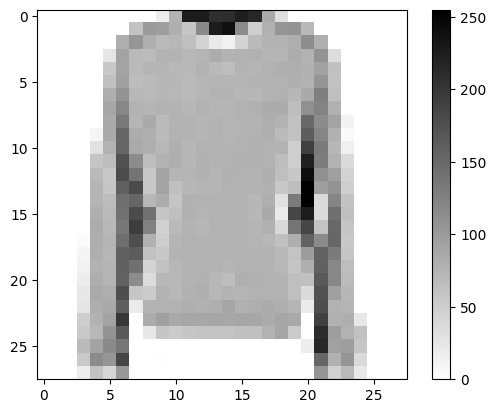

In [8]:
for imagen, etiqueta in datos_entrenamiento. take(1):
    break
imagen = imagen.numpy ().reshape((28,28)) #Redimensionar Los pixeles

#Dibujar dibujar
plt.figure()
plt.imshow (imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

W0000 00:00:1773102262.800546 24924779 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1773102262.800593 24924779 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


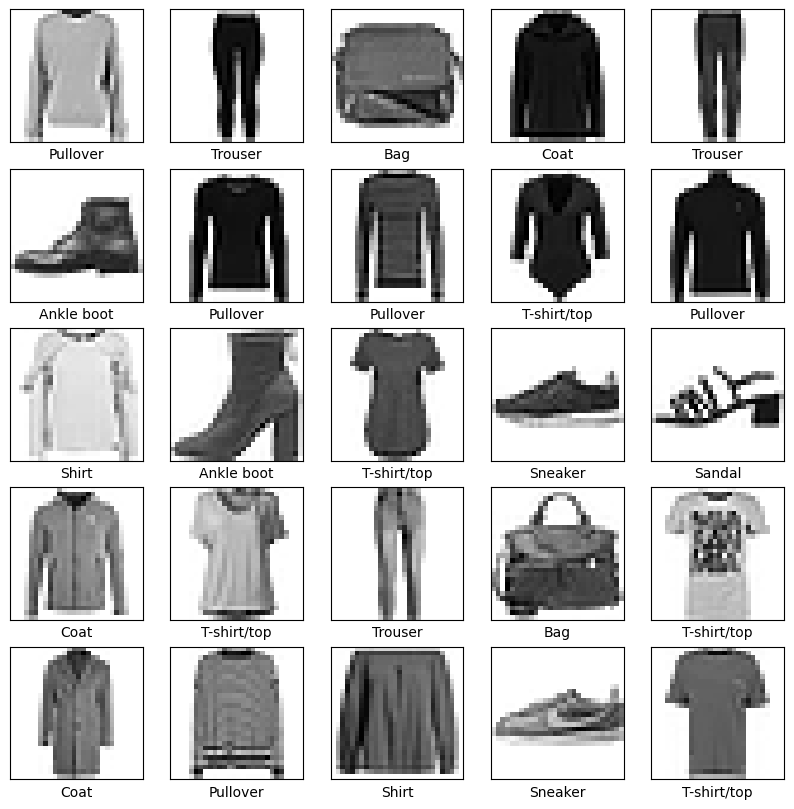

In [9]:
plt. figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28,28))
    plt.subplot(5,5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
plt.show()

In [10]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)), #1 - blanco y negro
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax) 
])

/opt/anaconda3/envs/uni-tf311/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [12]:
TAMANO_LOTE = 32

In [13]:
num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples
print(num_ej_entrenamiento)
print(num_ej_pruebas)
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

60000
10000


In [14]:
historial = modelo.fit(datos_entrenamiento, epochs=5, steps_per_epoch= math.ceil(num_ej_entrenamiento/TAMANO_LOTE))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 430us/step - accuracy: 0.6993 - loss: 1.8135
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 417us/step - accuracy: 0.7715 - loss: 0.6796
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 420us/step - accuracy: 0.7841 - loss: 0.6358
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 416us/step - accuracy: 0.7976 - loss: 0.6034
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 413us/step - accuracy: 0.8045 - loss: 0.5722


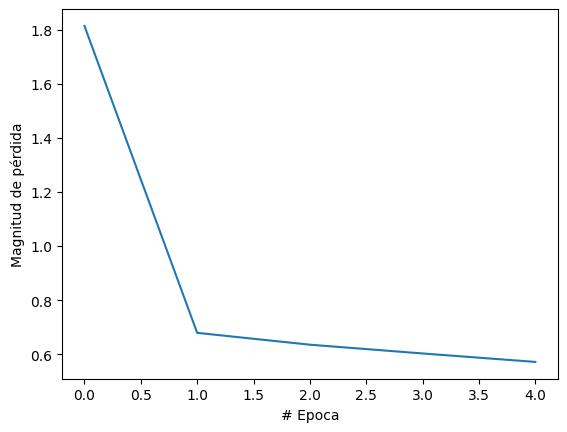

In [15]:
plt.xlabel("# Epoca")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])

In [16]:
#Crear una cuadricula con varias predicciones, y marcar si fue correcta (azul) o incorrecta (roja)
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba. numpy()
    
predicciones = modelo.predict(imagenes_prueba)
def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones [i], etiquetas_reales [i], imagenes [i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    
    plt.imshow(img[...,0], cmap=plt.cm.binary)
    
    etiqueta_prediccion = np.argmax(arr_predicciones)
    if etiqueta_prediccion == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'
        
plt.xlabel("{} {:2.0f}% ({})".format(nombres_clases[etiqueta_prediccion],
                                      100*np.max(arr_predicciones),
                                      nombres_clases[etiqueta_real]),
                                      color=color)


def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones [i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks ([])
    plt.yticks([])
    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0, 1])
    etiqueta_prediccion = np.argmax(arr_predicciones)
    
    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')
    
filas = 5
columnas = 5
num_imagenes = filas*columnas
plt.figure(figsize=(2*2*columnas, 2*filas))
for i in range (num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


W0000 00:00:1773102267.696938 24924985 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1773102267.697035 24924985 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


NameError: name 'etiqueta_prediccion' is not defined

In [17]:
imagen = imagenes_prueba[24]
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)
print("Prediccion:" + nombres_clases [np. argmax (prediccion [0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediccion:Dress


# PREGUNTAS
Parametro:
as_supervised:

Este parámetro indica si el conjunto de datos debe cargarse en un formato supervisado, es decir, separando cada ejemplo en una entrada y una salida esperada. Cuando se usa as_supervised=True, el dataset entrega los datos como pares (entrada, etiqueta), por ejemplo una imagen y su clase correspondiente. Esto facilita el entrenamiento de modelos de aprendizaje supervisado, ya que Keras y TensorFlow trabajan de forma directa con ese formato.

with_info:

Este parámetro indica si, además de cargar el conjunto de datos, se desea obtener información adicional sobre él. Cuando se usa with_info=True, TensorFlow devuelve también un objeto con metadatos del dataset, como el número de ejemplos de entrenamiento y prueba, los nombres de las clases y la estructura de las variables. Esto es útil para conocer mejor el conjunto de datos antes de entrenar el modelo.

Investigar ¿qué es el formato h5 y para que sirve?
El formato .h5 es un tipo de archivo usado para guardar modelos entrenados, datos y estructuras complejas. Viene de HDF5 (Hierarchical Data Format version 5), un formato diseñado para almacenar grandes cantidades de información de manera organizada.
En el contexto de TensorFlow o Keras, el archivo .h5 sirve principalmente para guardar un modelo de red neuronal completo.

Esto permite que, una vez entrenado el modelo, no tengas que volver a entrenarlo desde cero cada vez que quieras usarlo. Simplemente lo guardas en un archivo .h5 y luego lo vuelves a cargar cuando lo necesites.

In [18]:
modelo.save("modelo_fashion_mnist.h5")
print("Modelo guardado en formato .h5")

Modelo guardado en formato .h5


In [19]:
from ipywidgets import FileUpload
from IPython.display import display
from PIL import Image

In [20]:
def preparar_imagen(ruta_imagen):
    img = Image.open(ruta_imagen).convert("L")   # convertir a escala de grises
    img = img.resize((28, 28))                   # cambiar tamaño a 28x28
    
    img_array = np.array(img).astype("float32") / 255.0
    
    # Invertir colores si el fondo sale blanco y el objeto oscuro
    img_array = 1 - img_array
    
    plt.figure()
    plt.imshow(img_array, cmap="gray")
    plt.title("Imagen procesada")
    plt.axis("off")
    plt.show()
    
    img_array = img_array.reshape(1, 28, 28, 1)
    return img_array

In [21]:
def clasificar_imagen(ruta_imagen):
    imagen = preparar_imagen(ruta_imagen)
    prediccion = modelo.predict(imagen)
    
    clase_predicha = np.argmax(prediccion)
    confianza = np.max(prediccion) * 100
    
    print("Clase predicha:", nombres_clases[clase_predicha])
    print("Confianza: {:.2f}%".format(confianza))

In [24]:
uploader = FileUpload(accept='.png,.jpg,.jpeg', multiple=False)
display(uploader)

FileUpload(value=(), accept='.png,.jpg,.jpeg', description='Upload')

In [25]:
if uploader.value:
    archivo = list(uploader.value.values())[0]
    nombre_archivo = archivo['name']
    
    with open(nombre_archivo, 'wb') as f:
        f.write(archivo['content'])
    
    clasificar_imagen(nombre_archivo)
else:
    print("Primero sube una imagen en la celda anterior.")

Primero sube una imagen en la celda anterior.


In [26]:
modelo.save("modelo_fashion_mnist.h5")
print("Modelo guardado en formato .h5")

Modelo guardado en formato .h5
